# Parte 1 — Escolha e Análise do Dataset

1. Dataset escolhido: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

2. Motivo da escolha: Distúrbios do sono afetam milhões de pessoas no mundo todos os anos, causando um grande impacto na qualidade de vida daqueles que os desenvolvem. Distúrbios como apneia do sono e insônia estão ligados a fatores como obesidade, falta de atividade física, níveis de estresse, pressão sanguínea, entre outros. O dataset encapsula dados como qualidade e duração do sono, idade, entre outros já citados para identificar quais são fatores-chave para determinar se uma pessoa apresenta ou apresentará distúrbios do sono ou não.

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

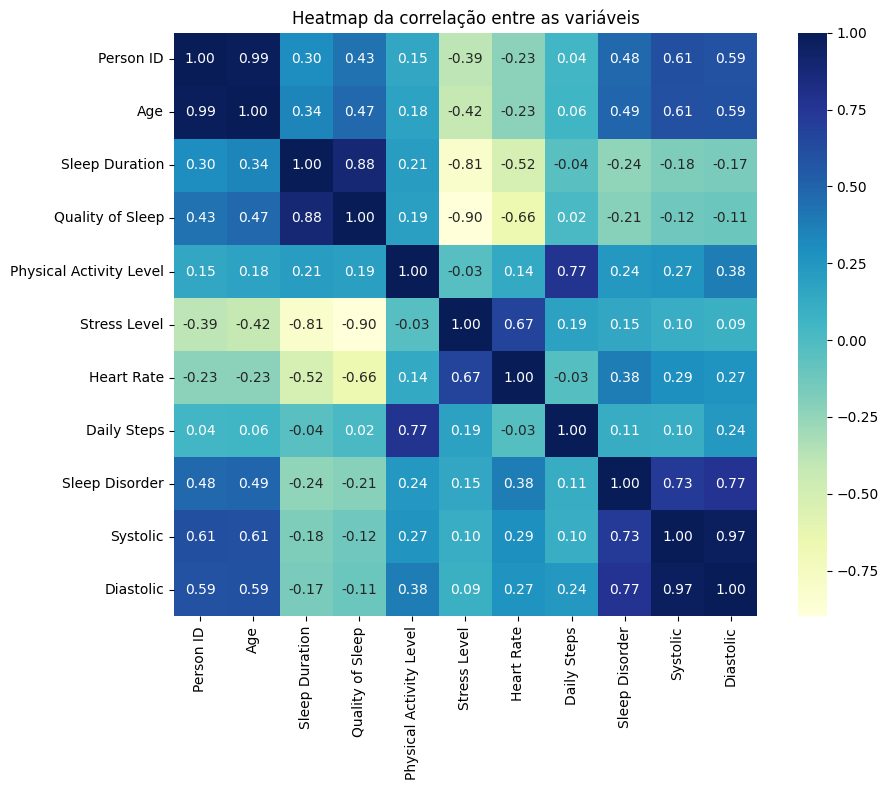

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
# Importando o dataset
file_id = "1am6bM8ZEdcRdplWJc5FU5NF7RdkD-5UN"
url = f"https://docs.google.com/uc?id={file_id}"
df = pd.read_csv(url)

print(df.head())
print("-"*50)
# Sleep Disorder tem muitos valores null que, nesse contexto, significam que alguém não tem distúrbios de sono.
# Realizar transformação dos valores nulos em "Sem distúrbio" e codificar a variável alvo Sleep Disorder
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder")
df["Sleep Disorder"] = df["Sleep Disorder"].map({"No Disorder": 0, "Insomnia": 1, "Sleep Apnea": 2})

# Separando a coluna string "Blood Pressure" em duas novas colunas "Systolic" e "Diastolic"
df[["Systolic", "Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True).astype(int)
df.drop(columns=["Blood Pressure"], inplace=True)

# HeatMap de correlação entre variáveis
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", square=True, cmap="YlGnBu")
plt.title("Heatmap da correlação entre as variáveis")
plt.tight_layout()
plt.show()
# Há muito mais pessoas que não apresentam distúrbios do que as que sim. Vou fazer uso de undersampling para equilibrar a distribuição das classes
X = df.drop(columns=["Sleep Disorder", "Person ID"])
y = df["Sleep Disorder"]
undersample = RandomUnderSampler(sampling_strategy="majority", random_state=42)
X_under, y_under = undersample.fit_resample(X, y)
X_under["BMI Category"] = X_under["BMI Category"].replace({"Normal Weight": "Normal"})

# Particionamento dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_under, y_under, test_size=0.2, random_state=42, stratify=y_under)
# Realizando encoding
le_gender = LabelEncoder()
X_train["Gender"] = le_gender.fit_transform(X_train["Gender"])
X_test["Gender"] = le_gender.transform(X_test["Gender"])

le_bmi = LabelEncoder()
X_train["BMI Category"] = le_bmi.fit_transform(X_train["BMI Category"])
X_test["BMI Category"] = le_bmi.transform(X_test["BMI Category"])

ohe = OneHotEncoder(drop="first", sparse_output=False)
X_train_encoded = pd.DataFrame(ohe.fit_transform(X_train[["Occupation"]]), columns=ohe.get_feature_names_out(["Occupation"]))
X_test_encoded = pd.DataFrame(ohe.transform(X_test[["Occupation"]]), columns=ohe.get_feature_names_out(["Occupation"]))
X_train_encoded.index = X_train.index
X_test_encoded.index = X_test.index

# Concatenando de volta
X_train = pd.concat([X_train.drop(columns=["Occupation"]), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=["Occupation"]), X_test_encoded], axis=1)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def plot_confusion_matrix(model, X_test, y_test, model_name):
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(5, 4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=["No Disorder", "Insomnia", "Sleep Apnea"], yticklabels=["No Disorder", "Insomnia", "Sleep Apnea"])
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(f"{model_name} Confusion Matrix")
  plt.tight_layout()
  plt.show()

# Parte 2 — Modelos escolhidos: SVM, Árvore de Decisão e Regressão Logística

In [ ]:
# Criando os modelos
models = {
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42)
}

results_base = {}
# Ajustando os modelos
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_proba, multi_class="ovr")
    results_base[name] = {
        "y_pred": y_pred,
        "auc": auc,
        "report": classification_report(y_test, y_pred, output_dict=True)
    }
    print(f"{name} - AUC-ROC (OvR): {auc:.4f}")
    print(f"{name} Classification Report:\n{classification_report(y_test, y_pred)}")
    print("-"*50)

SVM - AUC-ROC (OvR): 0.9417
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        16
           1       0.81      0.87      0.84        15
           2       0.92      0.75      0.83        16

    accuracy                           0.85        47
   macro avg       0.86      0.85      0.85        47
weighted avg       0.86      0.85      0.85        47

--------------------------------------------------
Decision Tree - AUC-ROC (OvR): 0.8665
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.78      0.93      0.85        15
           2       0.89      0.50      0.64        16

    accuracy                           0.79        47
   macro avg       0.81      0.79      0.77        47
weighted avg       0.81      0.79      0.77        47

--------------------------------------------------
Logist

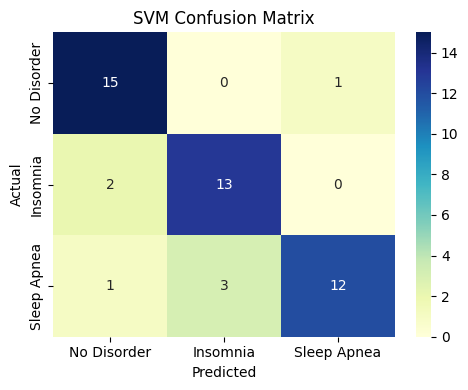

--------------------------------------------------


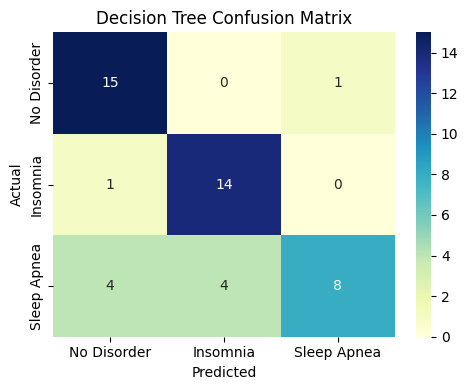

--------------------------------------------------


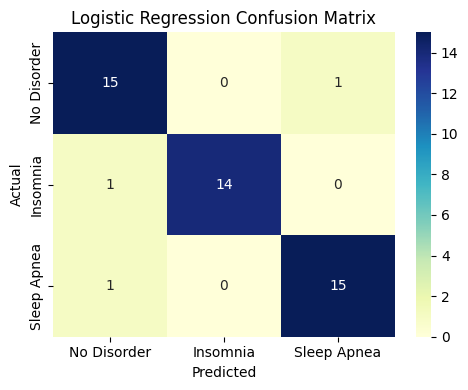

--------------------------------------------------


In [ ]:
for name, result in results_base.items():
  plot_confusion_matrix(models[name], X_test, y_test, name)
  print("-"*50)

# 2.3 - Vantagens e limitações de cada um dos modelos

Regressão Logística: Obteve os melhores resultados, com ROC-AUC de 95%, sendo o modelo com melhor curva dos resultados positivos sobre os negativos. A regressão logística é um modelo bem simples e facilmente interpretável, sendo adequada quando temos relações lineares entre as variáveis, que é o caso aqui. Entre suas desvantagens, está o fato de não ser um bom modelo quando temos muitas interações não lineares entre variáveis, ou quando não podemos assumir linearidade entre os dados, que é um preceito básico desse tipo de modelo.

SVM: O segundo melhor modelo no geral, Support Vector Machine tem pontos a seu favor como sua grande efetividade em datasets pequenos, mesmo aqueles com espaços altamente dimensionais, e tende a ser robusto a overfitting. No entanto, torna-se computacionalmente caro para datasets muito grandes, não é tão simples de interpretar, e depende bastante da escolha do kernel e dos outros parâmetros.

Árvores de Decisão: O modelo de pior desempenho para esse problema, mas um excelente modelo no geral. É muito fácil de interpretar seus resultados, são rápidas de treinar e testar e lida bem com diferentes tipos de dados sem normalização. Entretanto, caso seja permitida crescer sem uma poda ou controle de tamanho, pode rapidamente gerar overfitting, perdendo sua capacidade de generalizar.

# Parte 3 - Ensemble Learning: Random Forest, GradientBoosting e Stacking

In [ ]:
# Ensemble Models
ensemble_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Stacking": StackingClassifier(
        estimators=[
            ("svm", SVC(probability=True, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("lr", LogisticRegression(random_state=42))
        ],
        final_estimator=LogisticRegression(random_state=42), cv=5
    )
}
results_ensenbles = {}

# Ajustando os ensembles
for name, model in ensemble_models.items():
  scores = cross_val_score(model, X_train, y_train, cv=5)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)
  auc = roc_auc_score(y_test, y_proba, multi_class="ovr")
  results_ensenbles[name] = {
      "y_pred": y_pred,
      "auc": auc,
      "report": classification_report(y_test, y_pred, output_dict=True)
  }
  print(f"{name} - AUC-ROC (OvR): {auc:.4f}")
  print(f"{name} Classification Report:\n{classification_report(y_test, y_pred)}")
  print("-"*50)

Random Forest - AUC-ROC (OvR): 0.9094
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        16
           1       0.81      0.87      0.84        15
           2       0.86      0.75      0.80        16

    accuracy                           0.85        47
   macro avg       0.85      0.85      0.85        47
weighted avg       0.85      0.85      0.85        47

--------------------------------------------------
Gradient Boosting - AUC-ROC (OvR): 0.8976
Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        16
           1       0.87      0.87      0.87        15
           2       0.88      0.88      0.88        16

    accuracy                           0.87        47
   macro avg       0.87      0.87      0.87        47
weighted avg       0.87      0.87      0.87        47

-----------------------------

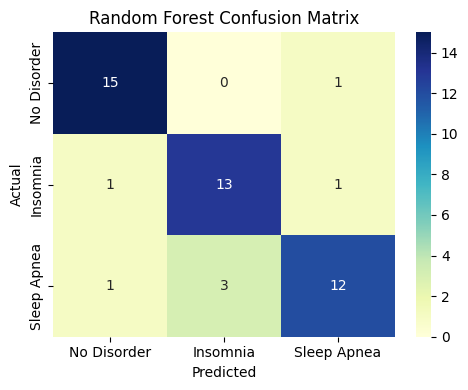

--------------------------------------------------


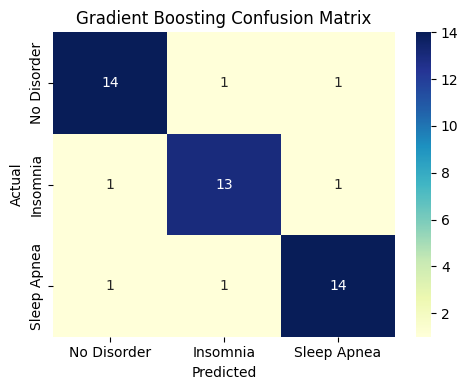

--------------------------------------------------


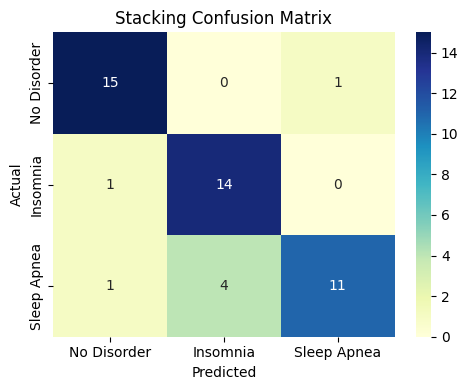

--------------------------------------------------


In [ ]:
for name, result in results_ensenbles.items():
  plot_confusion_matrix(ensemble_models[name], X_test, y_test, name)
  print("-"*50)

# Análise de desempenho dos Ensembles



# Parte 4 - Análise Comparativa e Discussão

Cada Ensemble teve vantagem em alguma métrica específica, algo bem curioso. O Random Forest teve a maior acurácia, o que indica que foi o que mais acertou as previsões, O Gradient Boosting teve o maior AUC-ROC, indicando que foi o que melhor distingiu entre as classes, e o Stacking teve um bom desempenho no geral, mas não superou os outros em definitivo em nenhuma métrica. No contexto de determinar se um paciente terá distúrbios do sono, provavelmente a melhor escolha entre os ensembles seria o GradientBoosting.

<Figure size 1200x600 with 0 Axes>

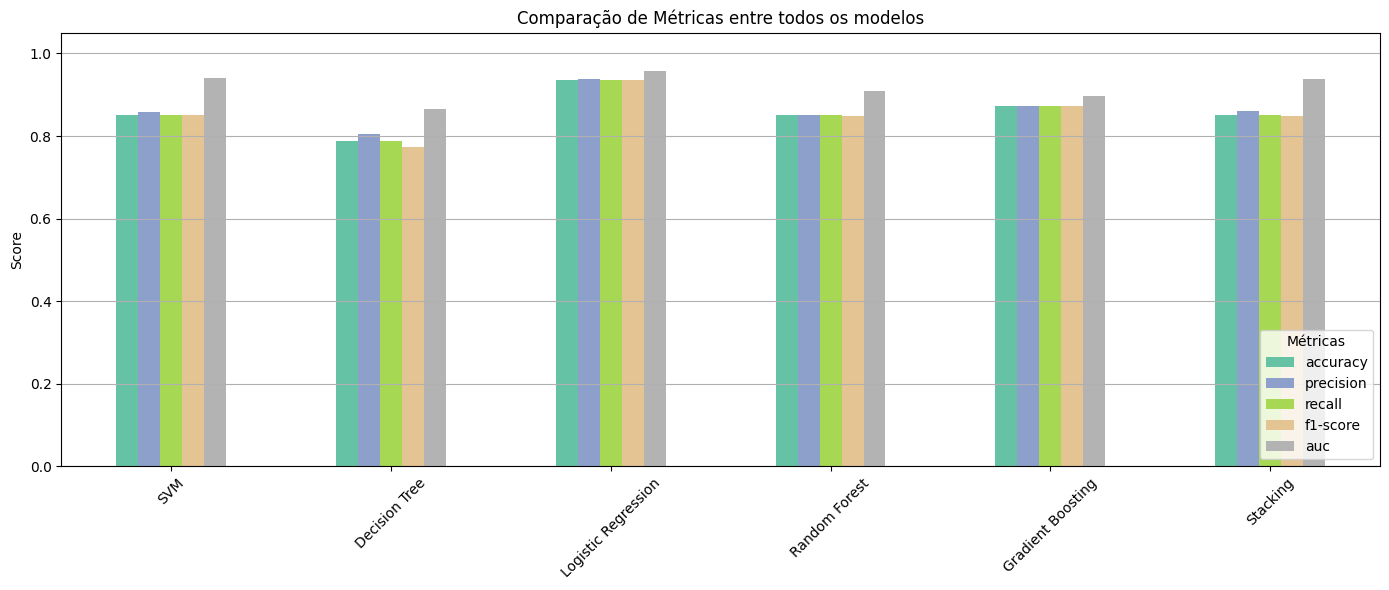

In [ ]:
all_models = {**results_base, **results_ensenbles}
metrics = ["accuracy", "precision", "recall", "f1-score", "auc"]
models_names = []
metrics_values = {m: [] for m in metrics}
for name, res in all_models.items():
  report = res["report"]
  metrics_values["accuracy"].append(report["accuracy"])
  metrics_values["precision"].append(report["weighted avg"]["precision"])
  metrics_values["recall"].append(report["weighted avg"]["recall"])
  metrics_values["f1-score"].append(report["weighted avg"]["f1-score"])
  metrics_values["auc"].append(res["auc"])
  models_names.append(name)

df_metrics = pd.DataFrame(metrics_values, index=models_names)
plt.figure(figsize=(12,6))
df_metrics.plot(kind = "bar", figsize=(14,6), colormap="Set2")
plt.title("Comparação de Métricas entre todos os modelos")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(title="Métricas", loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
tabela = []
for name, metrics in all_models.items():
  tabela.append([name, metrics["report"]["accuracy"], metrics["report"]["weighted avg"]["precision"], metrics["report"]["weighted avg"]["recall"], metrics["report"]["weighted avg"]["f1-score"], metrics["auc"]])
df_tabelado = pd.DataFrame(tabela, columns=["Modelo", "Acurácia", "Precisão (Macro)", "Recall (Macro)", "F1-Score (Macro)", "AUC-ROC"])
df_tabelado.sort_values(by="Acurácia", ascending=False, inplace=True)
display(df_tabelado)

,Modelo,Acurácia,Precisão (Macro),Recall (Macro),F1-Score (Macro),AUC-ROC
2,Logistic Regression,0.936170,0.938673,0.936170,0.936770,0.956687
4,Gradient Boosting,0.872340,0.872340,0.872340,0.872340,0.897569
3,Random Forest,0.851064,0.851477,0.851064,0.849491,0.909397
0,SVM,0.851064,0.857235,0.851064,0.849780,0.941723
5,Stacking,0.851064,0.860659,0.851064,0.847748,0.939236
1,Decision Tree,0.787234,0.806147,0.787234,0.772353,0.866532


# Discussão final
Pelos resultados e valores de métricas, é provável que a Árvore de Decisão tenha sofrido overfitting, visto que não restringi seu crescimento no código.

A abordagem vencedora foi a Regressão Logística, pois foi a que teve melhores resultados em todas as métricas, superando até mesmo os ensembles considerada a importância da separação entre classes que a AUC-ROC representa e apresentando um bom valor de acurácia.

O modelo mais acurado também é o mais interpretável, pois fornece coeficientes de cada variável preditora, facilitando o entendimento de sua decisão e da relação entre a variável e o distúrbio de sono, então priorizando o fator da explicabilidade, ele é o que se deu melhor.

Como o Reg Log pode ser usado ou mal utilizado em cenário real?

Ele pode ser utilizado na identificação de indivíduos que tem maiores chances de desenvolver distúrbios do sono, auxiliando um profissional da saúde a dar um diagnóstico, bem como para ajudar a prescrever tratamentos personalizados baseados nas características de cada pessoa

Um exemplo de mal uso seria confiar cegamente em seus resultados sem ter uma avaliação médica do paciente, ou utiliz-a-lo em um contexto social em que as características das pessoas apresentem uma grande divergência das do que o modelo viu no treino.